# Emergency Complaint Analyzer — EDA & Dataset Preparation
### Aligned with SRS v2.0 — Phase 1 (Dataset Preparation)

This notebook takes your raw HumAID parquet files and weak_mapping_dataset.csv and produces:
- `dataset/processed/emergency_data.csv` — full cleaned dataset (text, label)
- `dataset/processed/train.csv` — 70% split
- `dataset/processed/val.csv` — 15% split
- `dataset/processed/test.csv` — 15% split
- `dataset/processed/historical_incidents.csv` — for ChromaDB (text, label, severity, timestamp)

**SRS classes:** `Fire` | `Flood` | `Medical` | `Accident` | `Other`

**Targets (SRS §1.3):** Fire≥1500, Flood≥1500, Medical≥2000, Accident≥1500, Other≥1000

---
## Cell 0 — Install dependencies
Run this once if pyarrow is not installed.

In [1]:
# Run once to install pyarrow for reading .parquet files
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'pyarrow', '-q'])
print('pyarrow ready')

pyarrow ready


---
## Cell 1 — Imports

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
import random
from collections import Counter
from datetime import datetime, timedelta
from sklearn.model_selection import train_test_split

# Reproducibility
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# Output directory — change this to match your project layout
PROCESSED_DIR = '../processed'
os.makedirs(PROCESSED_DIR, exist_ok=True)

print('All imports successful.')
print(f'Output directory: {os.path.abspath(PROCESSED_DIR)}')

All imports successful.
Output directory: d:\nlp project\dataset\processed


---
## Cell 2 — Load raw parquet files
Your dataset is **HumAID** (Humanitarian Aid dataset).
Columns: `tweet_text`, `class_label` (9 humanitarian action categories)

In [4]:
# Adjust these paths if your files are in a different location
RAW_DIR = '../raw'

df_train = pd.read_parquet(f'{RAW_DIR}/train-00000-of-00001.parquet')
df_val   = pd.read_parquet(f'{RAW_DIR}/validation-00000-of-00001.parquet')
df_test  = pd.read_parquet(f'{RAW_DIR}/test-00000-of-00001.parquet')

# Merge all splits — we will re-split ourselves later in SRS format
df_raw = pd.concat([df_train, df_val, df_test], ignore_index=True)

print(f'train rows : {len(df_train):,}')
print(f'val rows   : {len(df_val):,}')
print(f'test rows  : {len(df_test):,}')
print(f'total rows : {len(df_raw):,}')
print()
print('Columns:', df_raw.columns.tolist())
df_raw.head(5)

train rows : 53,531
val rows   : 7,793
test rows  : 15,160
total rows : 76,484

Columns: ['tweet_text', 'class_label']


,tweet_text,class_label
0,Powerful Ecuador quake kills at least 235: POR...,injured_or_dead_people
1,Im at awe and saddened with the #EcuadorEarthq...,rescue_volunteering_or_donation_effort
2,RT @RachelAndJun: Our hearts are with everyone...,sympathy_and_support
3,RT @noticias2000: Ecuador quake death toll has...,injured_or_dead_people
4,RT @pzf: BREAKING PHOTOS: Major damage reporte...,infrastructure_and_utility_damage


---
## Cell 3 — Inspect original class_label distribution
These are the raw HumAID labels — they describe the **humanitarian purpose** of a tweet, not the disaster type.

=== Original class_label distribution ===
class_label
rescue_volunteering_or_donation_effort    21278
other_relevant_information                12144
sympathy_and_support                       8931
infrastructure_and_utility_damage          8163
injured_or_dead_people                     7303
not_humanitarian                           6296
caution_and_advice                         5394
displaced_people_and_evacuations           3999
requests_or_urgent_needs                   2618
missing_or_found_people                     358
Name: count, dtype: int64

Total unique labels: 10


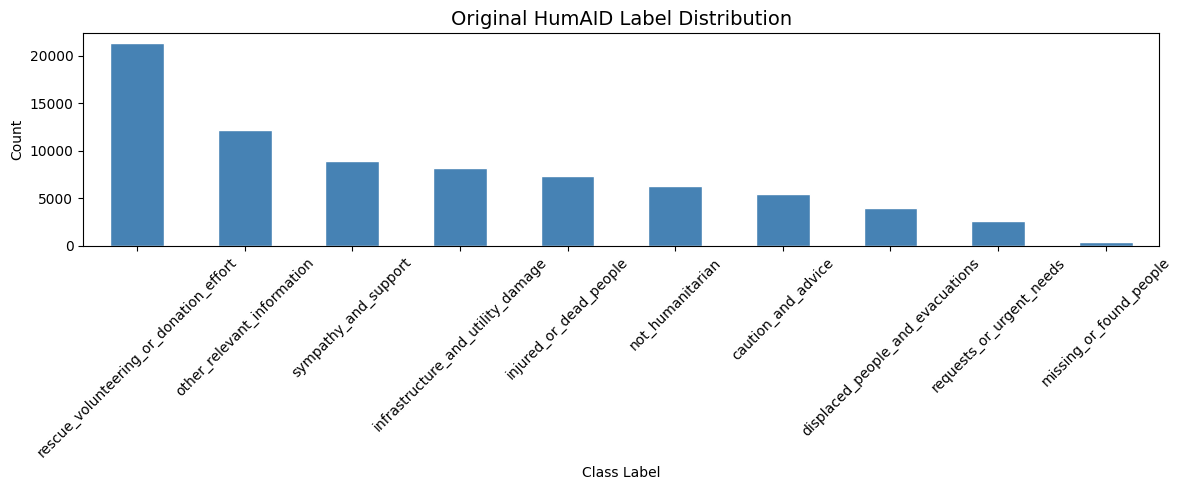

In [5]:
print('=== Original class_label distribution ===')
label_counts = df_raw['class_label'].value_counts()
print(label_counts)
print(f'\nTotal unique labels: {df_raw["class_label"].nunique()}')

fig, ax = plt.subplots(figsize=(12, 5))
label_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Original HumAID Label Distribution', fontsize=14)
ax.set_xlabel('Class Label')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

---
## Cell 4 — Basic data quality checks

In [6]:
print('=== Data Quality Report ===')
print(f'Total rows      : {len(df_raw):,}')
print(f'Null tweet_text : {df_raw["tweet_text"].isnull().sum()}')
print(f'Null class_label: {df_raw["class_label"].isnull().sum()}')
print(f'Duplicate rows  : {df_raw.duplicated().sum()}')
print(f'Duplicate tweets: {df_raw.duplicated(subset=["tweet_text"]).sum()}')
print()
print('Data types:')
print(df_raw.dtypes)

=== Data Quality Report ===
Total rows      : 76,484
Null tweet_text : 0
Null class_label: 0
Duplicate rows  : 6
Duplicate tweets: 6

Data types:
tweet_text     str
class_label    str
dtype: object


---
## Cell 5 — Text cleaning
Per SRS Phase 1 Step 1.4: lowercase, remove URLs, @mentions, hashtags, special chars.

In [7]:
def clean_text(text: str) -> str:
    """Clean tweet text per SRS §6 Phase 1 Step 1.4 preprocessing spec."""
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', '', text)      # remove URLs
    text = re.sub(r'@\w+', '', text)                   # remove @mentions
    text = re.sub(r'#(\w+)', r'\1', text)              # remove # but keep hashtag word
    text = re.sub(r'&amp;|&lt;|&gt;|&quot;', ' ', text) # HTML entities
    text = re.sub(r'[^a-z0-9\s]', ' ', text)           # keep only alphanumeric + space
    text = re.sub(r'\s+', ' ', text).strip()            # collapse whitespace
    return text

df_raw['clean_text'] = df_raw['tweet_text'].apply(clean_text)

# Drop nulls and duplicates on clean_text
before = len(df_raw)
df_raw = df_raw.dropna(subset=['clean_text', 'class_label'])
df_raw = df_raw.drop_duplicates(subset=['clean_text'])
df_raw = df_raw[df_raw['clean_text'].str.len() >= 10]  # drop very short texts
df_raw = df_raw.reset_index(drop=True)
after = len(df_raw)

print(f'Rows before cleaning : {before:,}')
print(f'Rows after cleaning  : {after:,}')
print(f'Rows removed         : {before - after:,}')
print()
print('Sample cleaned tweets:')
for i in range(3):
    print(f'  Original : {df_raw["tweet_text"].iloc[i][:80]}')
    print(f'  Cleaned  : {df_raw["clean_text"].iloc[i][:80]}')
    print()

Rows before cleaning : 76,484
Rows after cleaning  : 76,475
Rows removed         : 9

Sample cleaned tweets:
  Original : Powerful Ecuador quake kills at least 235: PORTOVIEJO - Rescuers in Ecuador race
  Cleaned  : powerful ecuador quake kills at least 235 portoviejo rescuers in ecuador raced t

  Original : Im at awe and saddened with the #EcuadorEarthquake Please any donations can help
  Cleaned  : im at awe and saddened with the ecuadorearthquake please any donations can help 

  Original : RT @RachelAndJun: Our hearts are with everyone in Kumamoto and Ecuador whos been
  Cleaned  : rt our hearts are with everyone in kumamoto and ecuador whos been affected by th



---
## Cell 6 — Text length analysis

=== Text Length Statistics ===
count    76475.000000
mean       128.913972
std         61.012072
min         12.000000
25%         85.000000
50%        111.000000
75%        164.000000
max        336.000000
Name: text_length, dtype: float64


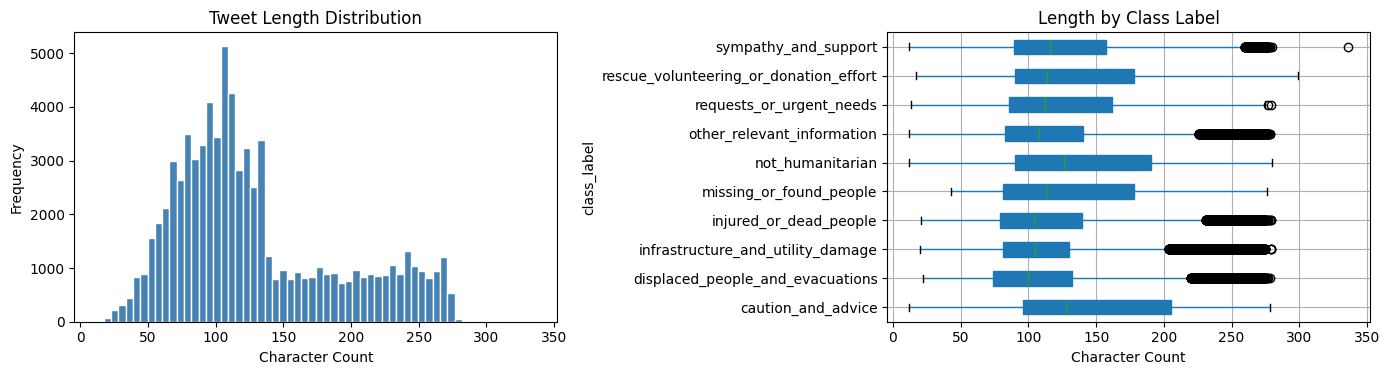

In [8]:
df_raw['text_length'] = df_raw['clean_text'].apply(len)

print('=== Text Length Statistics ===')
print(df_raw['text_length'].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df_raw['text_length'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Tweet Length Distribution')
axes[0].set_xlabel('Character Count')
axes[0].set_ylabel('Frequency')

# Box plot by class_label
df_raw.boxplot(column='text_length', by='class_label', ax=axes[1],
               vert=False, patch_artist=True)
axes[1].set_title('Length by Class Label')
axes[1].set_xlabel('Character Count')
plt.suptitle('')
plt.tight_layout()
plt.show()

---
## Cell 7 — Word frequency analysis

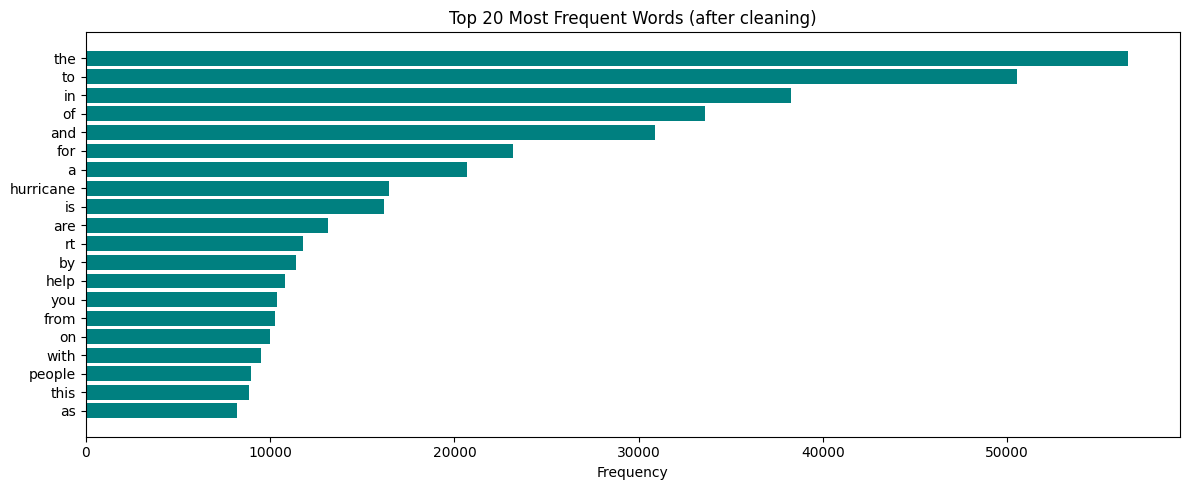

Top 50 words:
[('the', 56552), ('to', 50552), ('in', 38284), ('of', 33606), ('and', 30889), ('for', 23172), ('a', 20691), ('hurricane', 16477), ('is', 16185), ('are', 13160), ('rt', 11781), ('by', 11428), ('help', 10828), ('you', 10370), ('from', 10278), ('on', 9977), ('with', 9527), ('people', 8956), ('this', 8875), ('as', 8211), ('at', 8040), ('relief', 7845), ('we', 7486), ('have', 7203), ('our', 7105), ('all', 6944), ('that', 6906), ('earthquake', 6647), ('be', 6467), ('i', 6311), ('harvey', 6291), ('california', 5805), ('it', 5749), ('irma', 5722), ('has', 5687), ('damage', 5620), ('will', 5579), ('affected', 5542), ('flood', 5540), ('victims', 5516), ('kerala', 5322), ('can', 4938), ('dorian', 4930), ('please', 4924), ('more', 4866), ('s', 4804), ('after', 4696), ('water', 4619), ('my', 4383), ('those', 4379)]


In [9]:
all_words = ' '.join(df_raw['clean_text']).split()
word_freq = Counter(all_words)
top_words = word_freq.most_common(20)

words, counts = zip(*top_words)
fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(list(words)[::-1], list(counts)[::-1], color='teal')
ax.set_title('Top 20 Most Frequent Words (after cleaning)')
ax.set_xlabel('Frequency')
plt.tight_layout()
plt.show()

print('Top 50 words:')
print(word_freq.most_common(50))

---
## Cell 8 — Map to SRS 5-class labels

**Strategy:**
- HumAID `injured_or_dead_people` → **Medical** (content directly implies medical emergency)
- All other rows: use keyword matching on `clean_text` to detect **Fire**, **Flood**, **Accident**
- Priority order: Medical > Fire > Flood > Accident > Other

This is consistent with using your `weak_mapping_dataset.csv` keyword intelligence.

In [10]:
# === SRS 5-Class Label Mapping ===

# Keywords for each class — derived from weak_mapping_dataset.csv + SRS severity seeds
FIRE_KEYWORDS = [
    'fire', 'wildfire', 'bushfire', 'firefighter', 'arson', 'blaze',
    'smoke', 'burn', 'burnt', 'burning', 'flame', 'inferno',
    'wildland fire', 'forest fire', 'structure fire'
]

FLOOD_KEYWORDS = [
    'flood', 'flooding', 'floodwater', 'inundated', 'inundation',
    'hurricane', 'typhoon', 'tornado', 'twister', 'cyclone',
    'storm surge', 'flash flood', 'torrential', 'downpour',
    'tsunami', 'landslide', 'mudslide', 'storm', 'hurricane',
    'storm', 'torrential', 'overflow', 'levee', 'dam break'
]

MEDICAL_KEYWORDS = [
    'injured', 'injury', 'injuries', 'dead', 'death', 'deaths', 'died',
    'killed', 'casualties', 'casualty', 'fatalities', 'fatality',
    'unconscious', 'bleeding', 'trapped', 'missing', 'buried alive',
    'hospital', 'ambulance', 'medical emergency', 'first aid',
    'paramedic', 'wounded', 'survivor', 'drowning', 'collapsed'
]

ACCIDENT_KEYWORDS = [
    'accident', 'crash', 'collision', 'explosion', 'blast', 'bomb',
    'bombing', 'attack', 'terror', 'shooting', 'building collapse',
    'structural collapse', 'derailment', 'train crash', 'car crash',
    'plane crash', 'chemical spill', 'gas leak', 'toxic', 'hazmat'
]


def keyword_match(text: str, keywords: list) -> bool:
    """Return True if any keyword appears as a word/phrase in text."""
    for kw in keywords:
        pattern = r'\b' + re.escape(kw) + r'\b'
        if re.search(pattern, text):
            return True
    return False


def assign_srs_label(row) -> str:
    """
    Map HumAID class_label + tweet keywords to one of 5 SRS classes.
    Priority: Medical > Fire > Flood > Accident > Other
    """
    text = row['clean_text']
    humaid_label = str(row['class_label']).lower()

    # HumAID 'injured_or_dead_people' is a direct Medical signal
    if humaid_label == 'injured_or_dead_people':
        return 'Medical'

    # Keyword-based classification (priority order)
    if keyword_match(text, MEDICAL_KEYWORDS):
        return 'Medical'
    if keyword_match(text, FIRE_KEYWORDS):
        return 'Fire'
    if keyword_match(text, FLOOD_KEYWORDS):
        return 'Flood'
    if keyword_match(text, ACCIDENT_KEYWORDS):
        return 'Accident'

    # HumAID 'not_humanitarian' — these are usually noisy/irrelevant, put in Other
    if humaid_label == 'not_humanitarian':
        return 'Other'

    return 'Other'


print('Assigning SRS 5-class labels... (may take ~30 seconds)')
df_raw['label'] = df_raw.apply(assign_srs_label, axis=1)

print('Done!')
print()
print('=== SRS 5-Class Distribution ===')
new_dist = df_raw['label'].value_counts()
print(new_dist)
print()

# Check against SRS minimums
SRS_MINIMUMS = {'Fire': 1500, 'Flood': 1500, 'Medical': 2000, 'Accident': 1500, 'Other': 1000}
print('=== SRS Minimum Check ===')
all_pass = True
for cls, minimum in SRS_MINIMUMS.items():
    count = new_dist.get(cls, 0)
    status = '✅ PASS' if count >= minimum else '❌ NEED AUGMENTATION'
    if count < minimum:
        all_pass = False
    print(f'  {cls:<12}: {count:>6} / {minimum} required   {status}')

if all_pass:
    print('\n✅ All classes meet SRS minimums. No augmentation needed.')
else:
    print('\n⚠️  Some classes need augmentation — see Cell 9.')

Assigning SRS 5-class labels... (may take ~30 seconds)
Done!

=== SRS 5-Class Distribution ===
label
Other       38358
Flood       24150
Medical      9785
Fire         4050
Accident      132
Name: count, dtype: int64

=== SRS Minimum Check ===
  Fire        :   4050 / 1500 required   ✅ PASS
  Flood       :  24150 / 1500 required   ✅ PASS
  Medical     :   9785 / 2000 required   ✅ PASS
  Accident    :    132 / 1500 required   ❌ NEED AUGMENTATION
  Other       :  38358 / 1000 required   ✅ PASS

⚠️  Some classes need augmentation — see Cell 9.


---
## Cell 9 — Visualise the new 5-class distribution

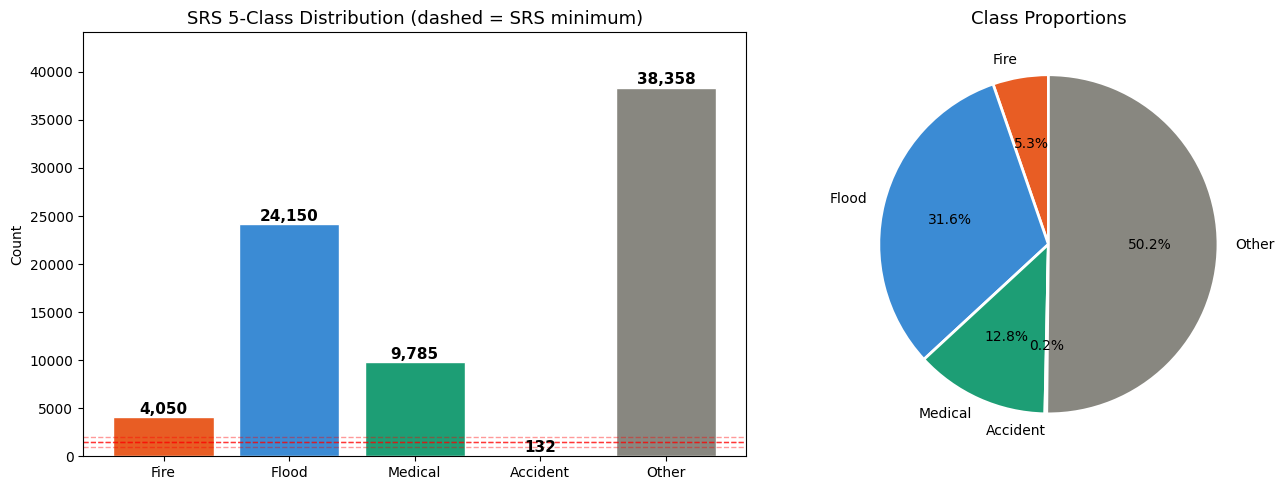

In [11]:
CLASS_COLORS = {
    'Fire':     '#E85D24',
    'Flood':    '#3B8BD4',
    'Medical':  '#1D9E75',
    'Accident': '#BA7517',
    'Other':    '#888780',
}

new_dist_sorted = df_raw['label'].value_counts().reindex(
    ['Fire', 'Flood', 'Medical', 'Accident', 'Other'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
bars = axes[0].bar(
    new_dist_sorted.index,
    new_dist_sorted.values,
    color=[CLASS_COLORS[c] for c in new_dist_sorted.index],
    edgecolor='white'
)
for bar, val in zip(bars, new_dist_sorted.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Draw SRS minimum lines
for cls, minimum in SRS_MINIMUMS.items():
    axes[0].axhline(y=minimum, color='red', linestyle='--', alpha=0.4, linewidth=1)

axes[0].set_title('SRS 5-Class Distribution (dashed = SRS minimum)', fontsize=13)
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, new_dist_sorted.max() * 1.15)

# Pie chart
axes[1].pie(
    new_dist_sorted.values,
    labels=new_dist_sorted.index,
    colors=[CLASS_COLORS[c] for c in new_dist_sorted.index],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Class Proportions', fontsize=13)

plt.tight_layout()
plt.show()

---
## Cell 10 — Synthetic data augmentation
If any class is below the SRS minimum, we generate synthetic examples here.
These are based on realistic citizen complaint patterns from the SRS examples.
**Skip this cell if all classes passed the minimum check in Cell 8.**

In [12]:
# === Synthetic sentence templates per class ===
# These follow the citizen complaint style described in SRS §1.2

SYNTHETIC_TEMPLATES = {
    'Fire': [
        'heavy smoke near {loc} building on {road}',
        'fire spreading through {loc} apartment block',
        'bushfire approaching residential area near {road}',
        'smoke and flames visible from {loc} factory',
        'firefighters responding to blaze at {loc}',
        'wildfire out of control near {loc} highway',
        'building on fire near {road} intersection',
        'explosion and fire at {loc} warehouse',
        'forest fire burning towards {loc} town',
        'grass fire on {road} spreading fast',
    ],
    'Flood': [
        'road completely flooded after heavy rain near {loc}',
        'cars submerged in floodwater on {road}',
        'flash flood warning issued for {loc} area',
        'homes inundated by floodwaters near {road}',
        'hurricane damage causing flooding in {loc}',
        'tornado warning active for {loc} county',
        'river burst banks flooding {loc} neighbourhood',
        'storm surge hitting {loc} coastal area',
        'torrential rain causing flooding on {road}',
        'evacuation ordered due to rising floodwaters in {loc}',
    ],
    'Medical': [
        'person unconscious near {loc} bus station not breathing',
        'multiple injuries after accident on {road}',
        'child trapped and injured near {loc}',
        'person collapsed on {road} needs ambulance',
        'several casualties reported at {loc}',
        'man bleeding heavily near {road} junction',
        'victim found unconscious near {loc} park',
        'people injured after building collapse at {loc}',
        'medical emergency near {road} missing persons',
        'drowning victim near {loc} riverbank needs help',
    ],
    'Accident': [
        'truck collision on {road} causing major injuries',
        'multiple vehicle crash on {road} highway',
        'explosion at {loc} gas station',
        'train derailment near {loc} station',
        'chemical spill on {road} hazmat situation',
        'building collapsed at {loc} workers trapped',
        'gas leak reported near {loc} residential block',
        'car crash on {road} serious damage',
        'blast reported at {loc} industrial area',
        'toxic fumes near {loc} factory evacuation needed',
    ],
    'Other': [
        'emergency services deployed to {loc}',
        'evacuation order issued for {loc} area',
        'rescue teams searching for missing persons near {loc}',
        'safety warning issued for {road} corridor',
        'disaster relief centre opened at {loc}',
        'troops deployed to assist civilians at {loc}',
        'crisis unfolding in {loc} emergency declared',
        'survivors found near {road} after incident',
        'volunteers needed at {loc} relief camp',
        'public safety alert for {loc} district',
    ],
}

LOCATIONS = [
    'downtown', 'north district', 'south suburb', 'main road', 'highway 12',
    'MG road', 'station road', 'park street', 'riverside', 'central market',
    'old city', 'new town', 'airport road', 'industrial zone', 'commercial area'
]

def generate_synthetic(label: str, count: int) -> list:
    """Generate 'count' synthetic examples for a given label."""
    templates = SYNTHETIC_TEMPLATES[label]
    rows = []
    for _ in range(count):
        template = random.choice(templates)
        loc  = random.choice(LOCATIONS)
        road = random.choice(LOCATIONS)
        text = template.format(loc=loc, road=road)
        rows.append({'clean_text': text, 'label': label, 'synthetic': True})
    return rows


# Mark original rows
df_raw['synthetic'] = False

# Generate augmentation only for classes below minimum
synthetic_rows = []
current_dist = df_raw['label'].value_counts()

for cls, minimum in SRS_MINIMUMS.items():
    current = current_dist.get(cls, 0)
    needed  = max(0, minimum - current)
    if needed > 0:
        print(f'Generating {needed:,} synthetic examples for class: {cls}')
        synthetic_rows.extend(generate_synthetic(cls, needed))
    else:
        print(f'{cls}: {current:,} rows — no augmentation needed')

if synthetic_rows:
    df_synth = pd.DataFrame(synthetic_rows)
    df_raw   = pd.concat([df_raw, df_synth], ignore_index=True)
    print(f'\nAdded {len(df_synth):,} synthetic rows.')
    print(f'New total: {len(df_raw):,} rows')
else:
    print('\nNo augmentation needed — all classes meet minimums.')

print()
print('=== Final Distribution After Augmentation ===')
print(df_raw['label'].value_counts())

Fire: 4,050 rows — no augmentation needed
Flood: 24,150 rows — no augmentation needed
Medical: 9,785 rows — no augmentation needed
Generating 1,368 synthetic examples for class: Accident
Other: 38,358 rows — no augmentation needed

Added 1,368 synthetic rows.
New total: 77,843 rows

=== Final Distribution After Augmentation ===
label
Other       38358
Flood       24150
Medical      9785
Fire         4050
Accident     1500
Name: count, dtype: int64


---
## Cell 11 — Final distribution check

=== FINAL SRS MINIMUM CHECK ===
  Fire        :   4050 / 1500   ✅ PASS
  Flood       :  24150 / 1500   ✅ PASS
  Medical     :   9785 / 2000   ✅ PASS
  Accident    :   1500 / 1500   ✅ PASS
  Other       :  38358 / 1000   ✅ PASS

✅ All classes meet SRS minimums. Ready to proceed.


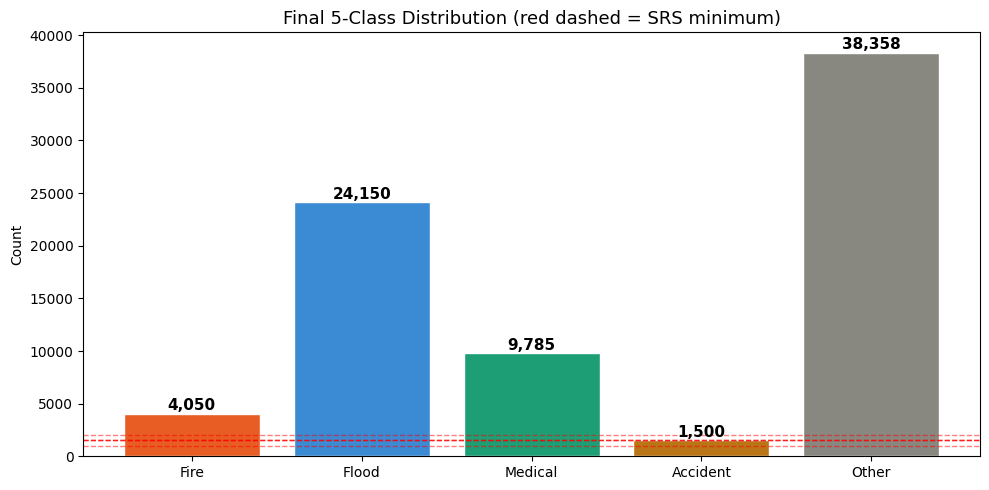

In [13]:
final_dist = df_raw['label'].value_counts().reindex(
    ['Fire', 'Flood', 'Medical', 'Accident', 'Other'])

print('=== FINAL SRS MINIMUM CHECK ===')
all_pass = True
for cls, minimum in SRS_MINIMUMS.items():
    count = final_dist.get(cls, 0)
    status = '✅ PASS' if count >= minimum else '❌ FAIL'
    if count < minimum:
        all_pass = False
    print(f'  {cls:<12}: {count:>6} / {minimum}   {status}')

print()
if all_pass:
    print('✅ All classes meet SRS minimums. Ready to proceed.')
else:
    print('❌ Some classes still below minimum. Increase synthetic template count and re-run Cell 10.')

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(
    final_dist.index,
    final_dist.values,
    color=[CLASS_COLORS[c] for c in final_dist.index],
    edgecolor='white'
)
for bar, val in zip(bars, final_dist.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')
for cls, minimum in SRS_MINIMUMS.items():
    ax.axhline(y=minimum, color='red', linestyle='--', alpha=0.5, linewidth=1)
ax.set_title('Final 5-Class Distribution (red dashed = SRS minimum)', fontsize=13)
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

---
## Cell 12 — Assign severity labels
Required for `historical_incidents.csv` (ChromaDB population, SRS §3.4) and Novelty ④ (Adaptive Severity Feedback).

Uses the same keyword weights as the SRS `INITIAL_WEIGHTS` seed (§3.3).

=== Severity Distribution ===
severity
High        50888
Low         20641
Moderate     4718
Critical     1596
Name: count, dtype: int64

=== Urgency Distribution ===
urgency
Urgent       50888
Normal       20641
Medium        4718
Immediate     1596
Name: count, dtype: int64


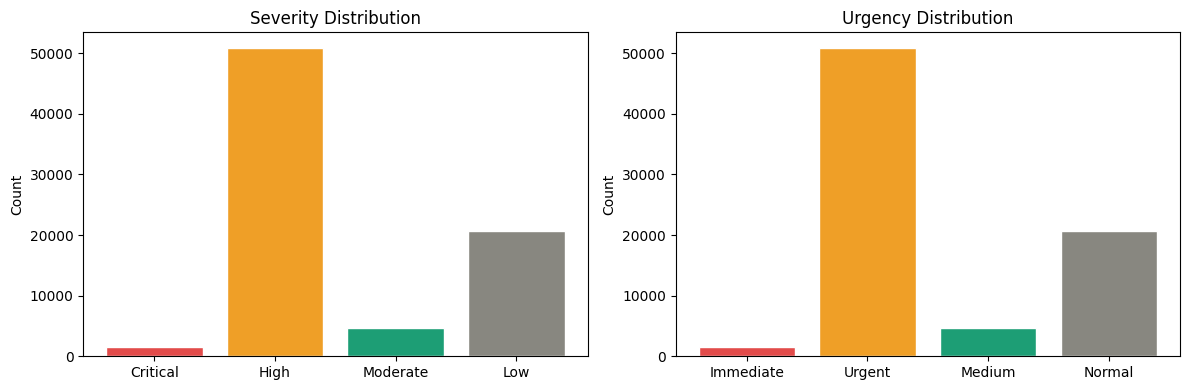

In [14]:
# Severity keyword tiers — from SRS §3.3 INITIAL_WEIGHTS
SEVERITY_KEYWORDS = {
    'Critical': [
        'explosion', 'collapsed', 'trapped', 'drowning', 'chemical',
        'buried alive', 'critical', 'mass casualty', 'building collapse',
        'gas leak', 'toxic', 'nuclear', 'structural collapse'
    ],
    'High': [
        'unconscious', 'bleeding', 'fire', 'flood', 'crash', 'hurricane',
        'tornado', 'wildfire', 'fatality', 'fatalities', 'killed', 'dead',
        'tsunami', 'multiple injuries', 'serious'
    ],
    'Moderate': [
        'injured', 'smoke', 'damage', 'injuries', 'missing', 'rescue',
        'evacuated', 'flooded', 'storm', 'accident', 'collision', 'moderate'
    ],
    'Low': [
        'warning', 'caution', 'imminent', 'safety', 'alert', 'prepare',
        'advisory', 'watch', 'monitor', 'threat'
    ],
}

def assign_severity(text: str) -> str:
    """Rule-based severity from tweet text. Priority: Critical > High > Moderate > Low."""
    t = text.lower()
    for level in ['Critical', 'High', 'Moderate', 'Low']:
        for kw in SEVERITY_KEYWORDS[level]:
            if kw in t:
                return level
    return 'Low'


# Urgency is derived from severity — per SRS §1.2
SEVERITY_TO_URGENCY = {
    'Critical': 'Immediate',
    'High':     'Urgent',
    'Moderate': 'Medium',
    'Low':      'Normal',
}

df_raw['severity'] = df_raw['clean_text'].apply(assign_severity)
df_raw['urgency']  = df_raw['severity'].map(SEVERITY_TO_URGENCY)

print('=== Severity Distribution ===')
print(df_raw['severity'].value_counts())
print()
print('=== Urgency Distribution ===')
print(df_raw['urgency'].value_counts())

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sev_colors = {'Critical':'#E24B4A','High':'#EF9F27','Moderate':'#1D9E75','Low':'#888780'}
sev_dist = df_raw['severity'].value_counts().reindex(['Critical','High','Moderate','Low'])
axes[0].bar(sev_dist.index, sev_dist.values,
            color=[sev_colors[s] for s in sev_dist.index], edgecolor='white')
axes[0].set_title('Severity Distribution')
axes[0].set_ylabel('Count')

urg_dist = df_raw['urgency'].value_counts().reindex(['Immediate','Urgent','Medium','Normal'])
axes[1].bar(urg_dist.index, urg_dist.values,
            color=['#E24B4A','#EF9F27','#1D9E75','#888780'], edgecolor='white')
axes[1].set_title('Urgency Distribution')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

---
## Cell 13 — Assign timestamps
Required for Novelty ③ (Temporal-Decayed Re-ranking).
Generates realistic timestamps spanning the last 3 years.

In [15]:
def random_timestamp(start_year: int = 2022, end_year: int = 2025) -> str:
    """Generate a random ISO-format timestamp within [start_year, end_year]."""
    start = datetime(start_year, 1, 1)
    end   = datetime(end_year, 12, 31)
    delta = end - start
    random_days = random.randint(0, delta.days)
    random_secs = random.randint(0, 86400)
    ts = start + timedelta(days=random_days, seconds=random_secs)
    return ts.isoformat()

df_raw['timestamp'] = [random_timestamp() for _ in range(len(df_raw))]

print(f'Timestamp range check:')
print(f'  Earliest : {df_raw["timestamp"].min()}')
print(f'  Latest   : {df_raw["timestamp"].max()}')
print(f'  Sample   : {df_raw["timestamp"].iloc[:3].tolist()}')

Timestamp range check:
  Earliest : 2022-01-01T00:01:00
  Latest   : 2025-12-31T22:52:17
  Sample   : ['2024-06-30T00:20:17', '2022-01-17T12:30:32', '2022-09-04T15:22:33']


---
## Cell 14 — Build final working dataframe
Keep only the columns needed by the SRS pipeline.

In [16]:
# Final dataframe — rename clean_text -> text as required by SRS
df_final = df_raw[['clean_text', 'label', 'severity', 'urgency', 'timestamp', 'synthetic']].copy()
df_final = df_final.rename(columns={'clean_text': 'text'})

# Shuffle
df_final = df_final.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print(f'Final dataset shape : {df_final.shape}')
print(f'Synthetic rows      : {df_final["synthetic"].sum():,}')
print(f'Real rows           : {(~df_final["synthetic"]).sum():,}')
print()
print('Sample rows:')
df_final.head(5)

Final dataset shape : (77843, 6)
Synthetic rows      : 1,368
Real rows           : 76,475

Sample rows:


,text,label,severity,urgency,timestamp,synthetic
0,a promise zero cash value show us a negotiable...,Flood,High,Urgent,2023-07-20T02:26:06,False
1,please stay informed about hurricane florence ...,Flood,High,Urgent,2023-01-05T10:48:08,False
2,flood watch remains in effect through tuesday ...,Flood,High,Urgent,2025-11-17T04:33:02,False
3,rt ecuador 7 8 magnitude earthquake video conf...,Other,Low,Normal,2025-11-07T12:34:18,False
4,breaking us official says a quarter of houses ...,Flood,High,Urgent,2022-11-10T23:10:46,False


---
## Cell 15 — Train / Val / Test split
Per SRS Phase 1 Step 1.4: 70% train, 15% val, 15% test with stratification.

In [17]:
# Split: 70% train, 15% val, 15% test (stratified on label)
df_train, df_temp = train_test_split(
    df_final, test_size=0.30, stratify=df_final['label'], random_state=RANDOM_STATE
)
df_val, df_test = train_test_split(
    df_temp, test_size=0.50, stratify=df_temp['label'], random_state=RANDOM_STATE
)

print(f'Train : {len(df_train):,} rows   ({len(df_train)/len(df_final)*100:.1f}%)')
print(f'Val   : {len(df_val):,} rows   ({len(df_val)/len(df_final)*100:.1f}%)')
print(f'Test  : {len(df_test):,} rows   ({len(df_test)/len(df_final)*100:.1f}%)')
print()

# Verify stratification
print('=== Label Distribution Per Split ===')
for name, split in [('Train', df_train), ('Val', df_val), ('Test', df_test)]:
    dist = split['label'].value_counts().to_dict()
    print(f'  {name}: {dist}')

Train : 54,490 rows   (70.0%)
Val   : 11,676 rows   (15.0%)
Test  : 11,677 rows   (15.0%)

=== Label Distribution Per Split ===
  Train: {'Other': 26851, 'Flood': 16905, 'Medical': 6849, 'Fire': 2835, 'Accident': 1050}
  Val: {'Other': 5753, 'Flood': 3622, 'Medical': 1468, 'Fire': 608, 'Accident': 225}
  Test: {'Other': 5754, 'Flood': 3623, 'Medical': 1468, 'Fire': 607, 'Accident': 225}


---
## Cell 16 — Save all output files
This produces every file required by the SRS training pipeline.

In [22]:
# ── 1. emergency_data.csv — Full dataset (text + label only, for training/train.py)
emergency_data = df_final[['text', 'label']]
emergency_data.to_csv(f'{PROCESSED_DIR}/emergency_data.csv', index=False)
print(f'✅ Saved emergency_data.csv       — {len(emergency_data):,} rows')

# ── 2. train.csv
df_train[['text', 'label']].to_csv(f'{PROCESSED_DIR}/train.csv', index=False)
print(f'✅ Saved train.csv                — {len(df_train):,} rows')

# ── 3. val.csv
df_val[['text', 'label']].to_csv(f'{PROCESSED_DIR}/val.csv', index=False)
print(f'✅ Saved val.csv                  — {len(df_val):,} rows')

# ── 4. test.csv
df_test[['text', 'label']].to_csv(f'{PROCESSED_DIR}/test.csv', index=False)
print(f'✅ Saved test.csv                 — {len(df_test):,} rows')

# ── 5. historical_incidents.csv — for ChromaDB (SRS §3.4)
#       Required columns: text, label, severity, timestamp
historical = df_final[['text', 'label', 'severity', 'timestamp']]
historical.to_csv(f'{PROCESSED_DIR}/historical_incidents.csv', index=False)
print(f'✅ Saved historical_incidents.csv — {len(historical):,} rows')

print()
print('=== All 5 SRS Required Files Saved ===')
for fname in ['emergency_data.csv', 'train.csv', 'val.csv', 'test.csv', 'historical_incidents.csv']:
    path = f'{PROCESSED_DIR}/{fname}'
    size_kb = os.path.getsize(path) / 1024
    print(f'  {fname:<35} {size_kb:>8.1f} KB')

✅ Saved emergency_data.csv       — 77,843 rows
✅ Saved train.csv                — 54,490 rows
✅ Saved val.csv                  — 11,676 rows
✅ Saved test.csv                 — 11,677 rows
✅ Saved historical_incidents.csv — 77,843 rows

=== All 5 SRS Required Files Saved ===
  emergency_data.csv                   10316.4 KB
  train.csv                             7200.3 KB
  val.csv                               1561.3 KB
  test.csv                              1554.9 KB
  historical_incidents.csv             12221.4 KB


---
## Cell 17 — Verify saved files (sanity check)

In [23]:
print('=== VERIFICATION — Loading saved files back ===')
print()

# Check emergency_data.csv
check = pd.read_csv(f'{PROCESSED_DIR}/emergency_data.csv')
print(f'emergency_data.csv:')
print(f'  Columns : {check.columns.tolist()}')
print(f'  Rows    : {len(check):,}')
print(f'  Labels  : {sorted(check["label"].unique().tolist())}')
print(f'  Nulls   : {check.isnull().sum().to_dict()}')
print()

# Check historical_incidents.csv
hist = pd.read_csv(f'{PROCESSED_DIR}/historical_incidents.csv')
print(f'historical_incidents.csv:')
print(f'  Columns   : {hist.columns.tolist()}')
print(f'  Rows      : {len(hist):,}')
print(f'  Severity  : {sorted(hist["severity"].unique().tolist())}')
print(f'  Timestamp sample: {hist["timestamp"].iloc[0]}')
print()

# Confirm train.py label_encoder will see all 5 classes
train_check = pd.read_csv(f'{PROCESSED_DIR}/train.csv')
print(f'train.csv labels present: {sorted(train_check["label"].unique().tolist())}')
assert sorted(train_check['label'].unique()) == ['Accident', 'Fire', 'Flood', 'Medical', 'Other'], \
    'ERROR: Missing label in train.csv'
print('✅ All 5 SRS labels present in train.csv')
print()
print('✅ Dataset preparation complete. Ready for SRS Phase 2 (DistilBERT training).')

=== VERIFICATION — Loading saved files back ===

emergency_data.csv:
  Columns : ['text', 'label']
  Rows    : 77,843
  Labels  : ['Accident', 'Fire', 'Flood', 'Medical', 'Other']
  Nulls   : {'text': 0, 'label': 0}

historical_incidents.csv:
  Columns   : ['text', 'label', 'severity', 'timestamp']
  Rows      : 77,843
  Severity  : ['Critical', 'High', 'Low', 'Moderate']
  Timestamp sample: 2023-07-20T02:26:06

train.csv labels present: ['Accident', 'Fire', 'Flood', 'Medical', 'Other']
✅ All 5 SRS labels present in train.csv

✅ Dataset preparation complete. Ready for SRS Phase 2 (DistilBERT training).


---
## Cell 18 — Full dataset summary report

In [24]:
print('=' * 55)
print('   EMERGENCY COMPLAINT ANALYZER — DATASET REPORT')
print('   SRS v2.0 Phase 1 Complete')
print('=' * 55)
print()
print(f'Source dataset     : HumAID (tweet_text + class_label)')
print(f'Total rows         : {len(df_final):,}')
print(f'  Real samples     : {(~df_final["synthetic"]).sum():,}')
print(f'  Synthetic        : {df_final["synthetic"].sum():,}')
print()
print('5-Class distribution:')
for cls in ['Fire', 'Flood', 'Medical', 'Accident', 'Other']:
    count = (df_final['label'] == cls).sum()
    bar   = '█' * (count // 200)
    print(f'  {cls:<12}: {count:>6,}  {bar}')
print()
print('Severity distribution:')
for sev in ['Critical', 'High', 'Moderate', 'Low']:
    count = (df_final['severity'] == sev).sum()
    print(f'  {sev:<12}: {count:>6,}')
print()
print('Splits:')
print(f'  train.csv        : {len(df_train):,} rows')
print(f'  val.csv          : {len(df_val):,} rows')
print(f'  test.csv         : {len(df_test):,} rows')
print()
print('SRS minimum check  :', '✅ ALL PASS' if all_pass else '❌ SOME FAIL')
print('Output directory   :', os.path.abspath(PROCESSED_DIR))
print()
print('Next step: Run training/train.py (SRS Phase 2)')
print('=' * 55)

   EMERGENCY COMPLAINT ANALYZER — DATASET REPORT
   SRS v2.0 Phase 1 Complete

Source dataset     : HumAID (tweet_text + class_label)
Total rows         : 77,843
  Real samples     : 76,475
  Synthetic        : 1,368

5-Class distribution:
  Fire        :  4,050  ████████████████████
  Flood       : 24,150  ████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  Medical     :  9,785  ████████████████████████████████████████████████
  Accident    :  1,500  ███████
  Other       : 38,358  ███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████

Severity distribution:
  Critical    :  1,596
  High        : 50,888
  Moderate    :  4,718
  Low         : 20,641

Splits:
  train.csv        : 54,490 rows
  val.csv          : 11,676 rows
  test.csv         : 11,677 rows

SRS minimum check  : ✅ A